# Multi‑Agent with LangGraph (Stateful Routing)

In [ ]:
!pip -q install langgraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.7/216.7 kB 15.7 MB/s eta 0:00:00


In [ ]:
import os, re, json, math, textwrap, time, hashlib, requests, operator
from typing import TypedDict, Literal, List, Dict, Any, Optional
from typing_extensions import Annotated
from google.colab import userdata
from langgraph.graph import StateGraph, END

In [ ]:
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')

In [ ]:
import google.generativeai as genai
genai.configure()

In [ ]:
GEMINI_MODEL = os.environ.get("GEMINI_MODEL", "gemini-2.0-flash")

In [ ]:
def gemini_chat(messages: List[Dict[str,str]], system: str = None) -> str:
    """Minimal wrapper for Gemini 2.0 Flash."""
    transcript = []
    if system:
        transcript.append(f"SYSTEM: {system}")
    for m in messages:
        transcript.append(f"{m['role'].upper()}: {m['content']}")
    prompt = "\n".join(transcript)
    model = genai.GenerativeModel(GEMINI_MODEL)
    resp = model.generate_content(prompt)
    return getattr(resp, "text", "").strip()

In [ ]:
os.environ["SERPER_API_KEY"] = userdata.get('SERPER_API_KEY')

In [ ]:
def serper_search(query: str, num: int = 8) -> Dict[str, Any]:
    url = "https://google.serper.dev/search"
    headers = {
        "X-API-KEY": os.environ["SERPER_API_KEY"],
        "Content-Type": "application/json",
    }
    payload = {"q": query, "num": num}
    r = requests.post(url, headers=headers, json=payload, timeout=30)
    r.raise_for_status()
    return r.json()

In [ ]:
# ---------------- State & Agents ----------------
class State(TypedDict, total=False):
    question: str
    route: Literal["search","code","explain","synthesize","done"]
    # Use additive channels for lists so multiple nodes/steps can extend safely.
    notes: Annotated[List[Dict[str, Any]], operator.add]
    sources: Annotated[List[str], operator.add]
    answer: str

def router(state: State):
    q = (state.get("question") or "").lower()
    if any(k in q for k in ["latest","today","news","update","current"]):
        return {"route": "search", "notes": [], "sources": []}  # init lists if absent
    elif any(k in q for k in ["code","snippet","implement","example"]):
        return {"route": "code", "notes": [], "sources": []}
    else:
        return {"route": "explain", "notes": [], "sources": []}

def agent_search(state: State):
    """Researcher: fetch results from Serper.dev and append."""
    results = serper_search(state["question"], num=8)
    notes, urls = [], []
    for sec in ("organic","news","topStories"):
        for it in (results.get(sec) or []):
            url = it.get("link")
            notes.append({
                "title": it.get("title"),
                "snippet": it.get("snippet"),
                "url": url
            })
            if url: urls.append(url)
    return {"notes": notes[:5], "sources": urls[:5], "route": "synthesize"}

def agent_explain(state: State):
    msg = gemini_chat(
        [{"role":"system","content":"You are a senior Python educator."},
         {"role":"user","content":state["question"]}]
    )
    return {"answer": msg, "route": "done"}

def agent_code(state: State):
    msg = gemini_chat(
        [{"role":"system","content":"Return minimal Python code with comments only."},
         {"role":"user","content":state["question"]}]
    )
    return {"answer": msg, "route": "done"}

def agent_synthesize(state: State):
    # Build compact context from latest notes (safe even if empty)
    latest = (state.get("notes") or [])[-5:]
    bullets = [f"- {it.get('title') or 'note'}: {it.get('snippet','')} ({it.get('url','')})" for it in latest]
    context = "\n".join(bullets) if bullets else "(no context gathered)"

    prompt = f"""Answer based on context below.
Question: {state['question']}

Context:
{context}

Format:
- 3–5 bullets
- Short conclusion
- List sources
"""
    msg = gemini_chat([{"role":"user","content":prompt}],
                      system="You are a research writer who always cites URLs.")
    uniq = list(dict.fromkeys(state.get("sources") or []))
    footer = "\n\nSources:\n" + "\n".join(f"- {u}" for u in uniq) if uniq else ""
    return {"answer": msg + footer, "route": "done"}

In [ ]:
g = StateGraph(State)
g.add_node("router", router)
g.add_node("search", agent_search)
g.add_node("explain", agent_explain)
g.add_node("code", agent_code)
g.add_node("synthesize", agent_synthesize)

g.set_entry_point("router")

# Using CONDITIONAL EDGES from router so only ONE child runs next:
def route_selector(s: State):
    return s["route"]

g.add_conditional_edges("router", route_selector, {
    "search": "search",
    "code": "code",
    "explain": "explain",
})

# After search, always synthesize
g.add_edge("search", "synthesize")

# End when a terminal node returns route="done"
g.add_conditional_edges("explain", lambda s: "done", {"done": END})
g.add_conditional_edges("code",    lambda s: "done", {"done": END})
g.add_conditional_edges("synthesize", lambda s: "done", {"done": END})

app = g.compile()

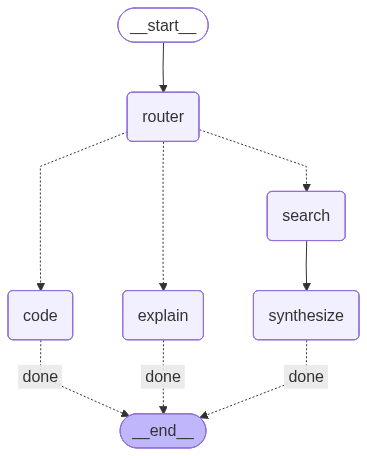

In [ ]:
app

In [ ]:
out1 = app.invoke({"question": "Give me a Python snippet to sort a list of numbers."})
print("=== CODE DEMO ===\n", out1["answer"], "\n")

=== CODE DEMO ===
 ```python
def sort_numbers(numbers):
  """Sorts a list of numbers in ascending order."""
  numbers.sort() # In-place sort using the built-in sort method.
  return numbers # Returns the sorted list.
``` 



In [ ]:
out2 = app.invoke({"question": "Latest Python 3.13 performance improvements"})
print("=== RESEARCH DEMO ===\n", out2["answer"])

=== RESEARCH DEMO ===
 Here's a summary of the performance improvements in Python 3.13:

*   **Free-Threaded Mode (Experimental):** Python 3.13 introduces experimental support for running in a free-threaded mode, which aims to remove the Global Interpreter Lock (GIL) and allow for better multi-core utilization (https://docs.python.org/3/whatsnew/3.13.html, https://thenewstack.io/python-3-13-blazing-new-trails-in-performance-and-scale/, https://codspeed.io/blog/state-of-python-3-13-performance-free-threading). This is particularly beneficial for multi-threaded CPU-bound tasks (https://dev.to/epam_india_python/python-313-the-gateway-to-high-performance-multithreading-without-gil-1dm7).
*   **Just-In-Time (JIT) Compiler:** An experimental JIT compiler is included in Python 3.13, potentially boosting performance (https://docs.python.org/3/whatsnew/3.13.html, https://thenewstack.io/python-3-13-blazing-new-trails-in-performance-and-scale/).
*   **Real-world Speedup:** While the free-threaded